In [4]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import pandas as pd

In [5]:
insurance_data=pd.read_csv("insurance.csv")

X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)

X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})

X["age_smoker"]=X["age"] * X["smoker"]
X["bmi_smoker"]=X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)




MSE for 0.001 : 20922599.87103596
MSE for 0.1 : 20921803.698431373
MSE for 1 : 20914832.63508914
MSE for 2 : 20908106.77995452
MSE for 5 : 20890881.000633497
MSE for 10 : 20872844.794796687
MSE for 20 : 20877828.532378826
MSE for 30 : 20937537.133939773
MSE for 40 : 21046489.29389078
MSE for 50 : 21196929.86960891
MSE for 100 : 22423172.686023246


<Axes: >

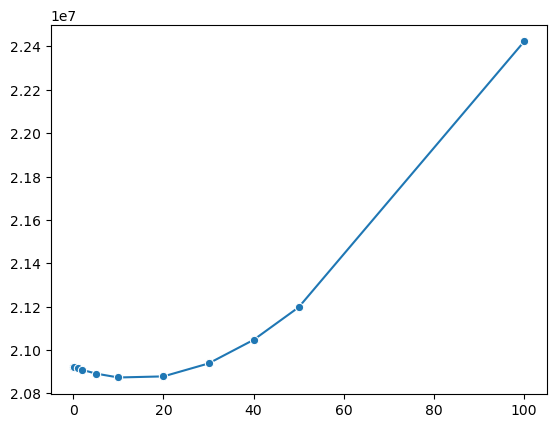

In [6]:
import seaborn as sns
alpha=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mse=[]
for a in alpha:
    lasso_model = linear_model.Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)

    y_pred=lasso_model.predict(X_test)
    mses=mean_squared_error(y_test,y_pred)
    print(f"MSE for {a} : {mses}")
    mse.append(mses)

sns.lineplot(x=alpha,y=mse,marker="o")

In [16]:
# Lassocv
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score
a=[0.001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42 
)
lasso_cv_model.fit(X_train,y_train)
print("Best alpha : ",lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mse : ",mse)
print("R2 :", r2 * 100)

Best alpha :  0.001
Mse :  20922599.87103596
R2 : 86.523174991517


In [15]:
# Ridgecv
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

ridge_cv_model = RidgeCV(
    alphas=a,
    cv=5,
    
)

ridge_cv_model.fit(X_train, y_train)

print("Best alpha :", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("R2 :", r2 * 100)


Best alpha : 0.001
MSE : 20922417.541202713
R2 : 86.52329243520333


In [10]:
# elastic net
from  sklearn.linear_model import ElasticNet

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

model = ElasticNet(
    alpha = 1.0,
    l1_ratio=0.5,
    max_iter=1000,
    random_state = 42
)

model.fit(X_train, y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [12]:
y_pred = model.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("R2 :", r2 * 100)

MSE : 22654508.40257189
R2 : 85.40760482556836
